In [8]:
import os.path as op
import arviz as az
from risk_experiment.cogmodels.fit_model import build_model, get_data

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Helvetica'
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.25, palette='tab10')

In [2]:
model_label = '12'
session = None
bids_folder = '/data/ds-risk'

cm = 1/2.54  # centimeters in inches

data = get_data(model_label, session, bids_folder,  None)#.drop('session', axis=1)
model = build_model(model_label, data, None)
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:01<00:00, 23.04it/s]


In [3]:
ppc = model.ppc(trace=idata.sel(draw=slice(None, None, 10)), data=data.drop('session', axis=1))

# "Chose risky" vs "chose 2nd option coding"
ppc.loc[ppc.index.get_level_values('risky_first')] = 1 - ppc.loc[ppc.index.get_level_values('risky_first')]


Sampling: [ll_bernoulli]


Plotting ppc type 1


/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:67: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:257: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


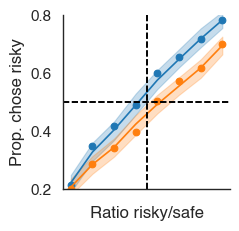

In [22]:
from risk_experiment.cogmodels.utils import plot_ppc
import numpy as np


height = 65. / 25.4
fac = plot_ppc(data, ppc, 1, level='group', legend=False, height=height)

# fac.fig.set_size_inches(6.4*cm, 6.4*cm)
fac.set(xlabel='Ratio risky/safe', xticks=np.arange(1, 9), xticklabels=['']*8, yticks=np.linspace(.2, .8, 4), ylim=[.2, .8])

fac.savefig('/data/ds-risk/derivatives/figures/order_effect_ppc.pdf')

Plotting ppc type 2


/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:257: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


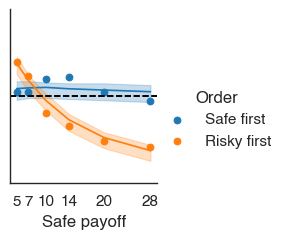

In [20]:
fac = plot_ppc(data, ppc, 2, level='group', legend=True, height=height)

fac.set(xlabel='Safe payoff', ylabel='', xticks=[5, 7, 10, 14, 20, 28], yticks=np.linspace(.2, .8, 7), yticklabels=['']*7, ylim=[.2, .8])

fac.savefig('/data/ds-risk/derivatives/figures/order_magnitude_effect_ppc.pdf')